In [ ]:
!wget -O general_stress_data.zip "https://next.phytlsigns.com/index.php/s/R89wDWHrW2Zzomb/download"

--2026-01-30 13:24:32--  https://next.phytlsigns.com/index.php/s/R89wDWHrW2Zzomb/download
Resolving next.phytlsigns.com (next.phytlsigns.com)... 81.17.18.218
Connecting to next.phytlsigns.com (next.phytlsigns.com)|81.17.18.218|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified [application/zip]
Saving to: ‘general_stress_data.zip’

general_stress_data     [           <=>      ]  23.73G  27.0MB/s    in 15m 35s 

2026-01-30 13:40:08 (26.0 MB/s) - ‘general_stress_data.zip’ saved [25479327673]



In [ ]:
!unzip general_stress_data.zip

Archive:  general_stress_data.zip
   creating: General Stress Data and Paper/
 extracting: General Stress Data and Paper/General Stress Paper.pdf  
 extracting: General Stress Data and Paper/GeneralStressPaperData.tar  
 extracting: General Stress Data and Paper/GeneralStress_SuppMat.pdf  
 extracting: General Stress Data and Paper/Readme (copy).txt  


In [ ]:
!tar -xf "/content/General Stress Data and Paper/GeneralStressPaperData.tar"

In [ ]:
!rm -f "/content/General Stress Data and Paper/GeneralStressPaperData.tar"

In [ ]:
!ls /content

 download			  general_stress_data.zip   sample_data
'General Stress Data and Paper'   GeneralStressPaperData


In [ ]:
!find /content -name "*.mat" | head -20

/content/GeneralStressPaperData/generalstress_drought_channelG3C1.mat
/content/GeneralStressPaperData/generalstress_spidermites_channelF0.mat
/content/GeneralStressPaperData/generalstress_deficitFe2+_channelG3.mat
/content/GeneralStressPaperData/generalstress_spidermites_channelC0.mat
/content/GeneralStressPaperData/generalstress_drought_channelG3C3.mat
/content/GeneralStressPaperData/generalstress_drought_channelG3C4.mat
/content/GeneralStressPaperData/generalstress_spidermites_channelC2.mat
/content/GeneralStressPaperData/generalstress_spidermites_channelC1.mat
/content/GeneralStressPaperData/generalstress_drought_channelG3C0.mat
/content/GeneralStressPaperData/generalstress_deficitN_channelC2.mat
/content/GeneralStressPaperData/generalstress_deficitFe2+_channelF7.mat
/content/GeneralStressPaperData/generalstress_deficitMn2+_channelB7.mat
/content/GeneralStressPaperData/generalstress_spidermites_channelF6.mat
/content/GeneralStressPaperData/generalstress_spidermites_channelD0.mat
/co

In [ ]:
import h5py
import numpy as np
import matplotlib.pyplot as plt


In [ ]:
mat_path = "/content/GeneralStressPaperData/generalstress_drought_channelG3C6.mat"

with h5py.File(mat_path, "r") as f:
    print("Top-level keys:", list(f.keys()))


Top-level keys: ['#refs#', '#subsystem#', 'calaxis', 'mV']


In [ ]:
with h5py.File(mat_path, "r") as f:
    signal = np.array(f["mV"]).squeeze()

print("Signal shape:", signal.shape)
print("Approx duration (hours):", signal.shape[0] / (500 * 3600))


Signal shape: (86362275,)
Approx duration (hours): 47.97904166666667


In [ ]:
fs = 500
samples_24h = int(24 * 3600 * fs)

signal_normal = signal[:samples_24h]
signal_stressed = signal[samples_24h:2*samples_24h]


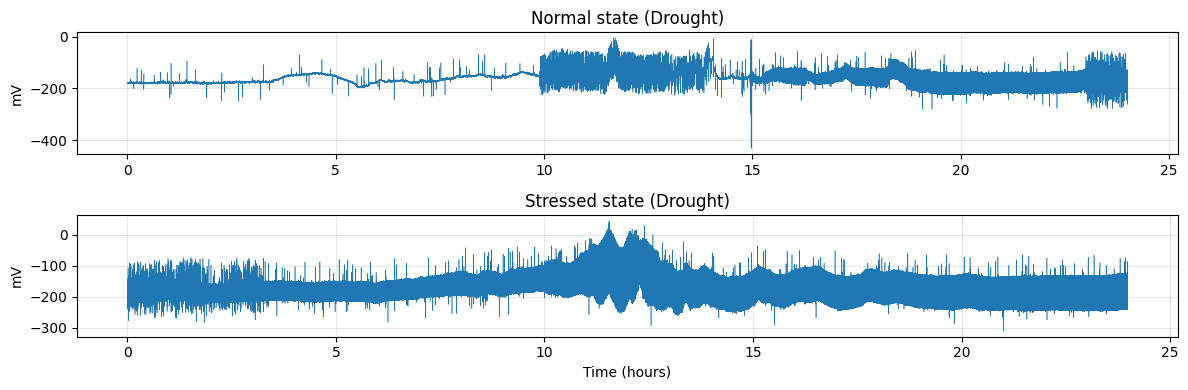

In [ ]:
t_normal = np.arange(len(signal_normal)) / fs / 3600
t_stressed = np.arange(len(signal_stressed)) / fs / 3600

plt.figure(figsize=(12, 4))

plt.subplot(2, 1, 1)
plt.plot(t_normal, signal_normal, linewidth=0.4)
plt.title("Normal state (Drought)")
plt.ylabel("mV")
plt.grid(alpha=0.3)

plt.subplot(2, 1, 2)
plt.plot(t_stressed, signal_stressed, linewidth=0.4)
plt.title("Stressed state (Drought)")
plt.xlabel("Time (hours)")
plt.ylabel("mV")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()


In [ ]:
import numpy as np
import matplotlib.pyplot as plt


samples_24h = int(24 * 3600 * fs)

def downsample_for_plot(sig, fs, target_fs=2.0):
    """Downsample by an integer factor to ~target_fs for plotting."""
    factor = max(1, int(round(fs / target_fs)))
    sig_ds = sig[::factor]
    fs_ds = fs / factor
    t_hours = np.arange(sig_ds.size) / fs_ds / 3600
    return t_hours, sig_ds

def shade_night(ax, night1=(0,6), night2=(18,24)):
    ax.axvspan(*night1, color="gray", alpha=0.25, lw=0)
    ax.axvspan(*night2, color="gray", alpha=0.25, lw=0)

def plot_paper_style(normal, stressed, fs=500, target_fs=2.0, title="Drought"):
    # Downsample for plotting
    tN, yN = downsample_for_plot(normal, fs, target_fs=target_fs)
    tS, yS = downsample_for_plot(stressed, fs, target_fs=target_fs)

    fig, axes = plt.subplots(2, 1, figsize=(10, 5), sharex=True)

    # Normal
    ax = axes[0]
    ax.plot(tN, yN, linewidth=0.8)
    shade_night(ax)
    ax.set_title(f"{title} (Normal state)")
    ax.set_ylabel("mV")
    ax.set_xlim(0, 24)
    ax.grid(alpha=0.2)

    # Stressed
    ax = axes[1]
    ax.plot(tS, yS, linewidth=0.8)
    shade_night(ax)
    ax.set_title(f"{title} (Stressed state)")
    ax.set_xlabel("Time (hours)")
    ax.set_ylabel("mV")
    ax.set_xlim(0, 24)
    ax.grid(alpha=0.2)

    plt.tight_layout()
    plt.show()


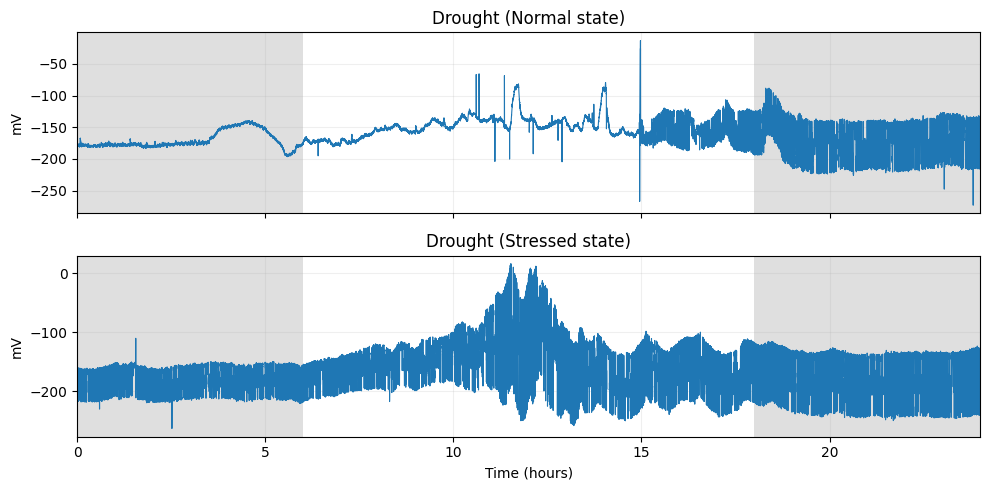

In [ ]:
signal_normal = signal[:samples_24h]
signal_stressed = signal[samples_24h:2*samples_24h]

plot_paper_style(signal_normal, signal_stressed, fs=500, target_fs=2.0, title="Drought")


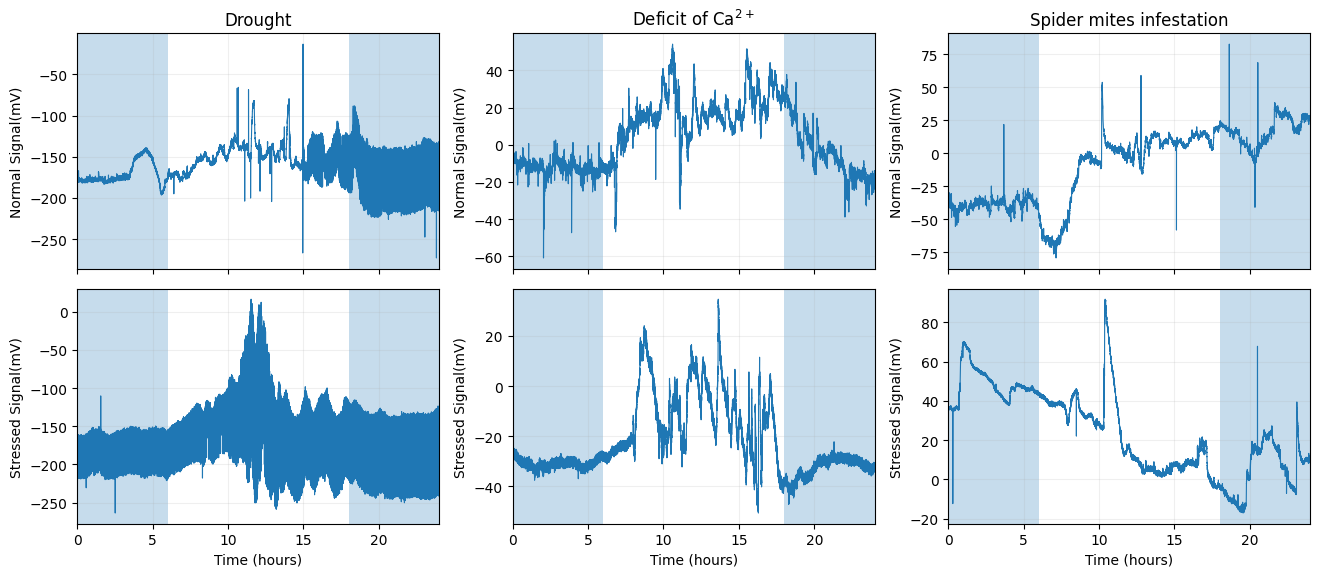

In [ ]:
import h5py
import numpy as np
import matplotlib.pyplot as plt

BASE = "/content/GeneralStressPaperData"


FILES = {
    "Drought": f"{BASE}/generalstress_drought_channelG3C6.mat",
    "Deficit of Ca$^{2+}$": f"{BASE}/generalstress_deficitCa2+_channelF5.mat",
    "Spider mites infestation": f"{BASE}/generalstress_spidermites_channelF6.mat",
}

samples_24h = int(24 * 3600 * fs)

def load_mv(mat_path):
    """Load the raw electrophysiological signal stored under key 'mV'."""
    with h5py.File(mat_path, "r") as f:
        sig = np.array(f["mV"]).squeeze()
    return sig

def downsample(sig, fs, target_fs=2.0):
    """Downsample by integer factor to ~target_fs for plotting."""
    factor = max(1, int(round(fs / target_fs)))
    sig_ds = sig[::factor]
    fs_ds = fs / factor
    t_hours = np.arange(sig_ds.size) / fs_ds / 3600
    return t_hours, sig_ds

def shade_night(ax):
    # gray blocks: night period
    ax.axvspan(0, 6, alpha=0.25, lw=0)
    ax.axvspan(18, 24, alpha=0.25, lw=0)

# Create figure: 2 rows (Normal/Stressed) x 3 columns (stress types)
fig, axes = plt.subplots(2, 3, figsize=(14, 6), sharex=True)

for col, (stress_name, path) in enumerate(FILES.items()):
    sig = load_mv(path)

    # split: first 24h normal, second 24h stressed
    normal = sig[:min(samples_24h, sig.size)]
    stressed = sig[min(samples_24h, sig.size):min(2*samples_24h, sig.size)]

    # downsample for clean plotting
    tN, yN = downsample(normal, fs, target_fs=2.0)
    tS, yS = downsample(stressed, fs, target_fs=2.0)

    # Normal
    ax = axes[0, col]
    ax.plot(tN, yN, linewidth=0.8)
    shade_night(ax)
    ax.set_title(stress_name)
    ax.set_ylabel("Normal Signal(mV)")
    ax.set_xlim(0, 24)
    ax.grid(alpha=0.2)


    #Stressed
    ax2 = axes[1, col]
    ax2.plot(tS, yS, linewidth=0.8)
    shade_night(ax2)
    ax2.set_ylabel("Stressed Signal(mV)")
    ax2.set_xlim(0, 24)
    ax2.grid(alpha=0.2)
    ax2.set_xlabel("Time (hours)")



plt.tight_layout(rect=[0.05, 0.02, 1, 1])
plt.show()



# After preprocessing

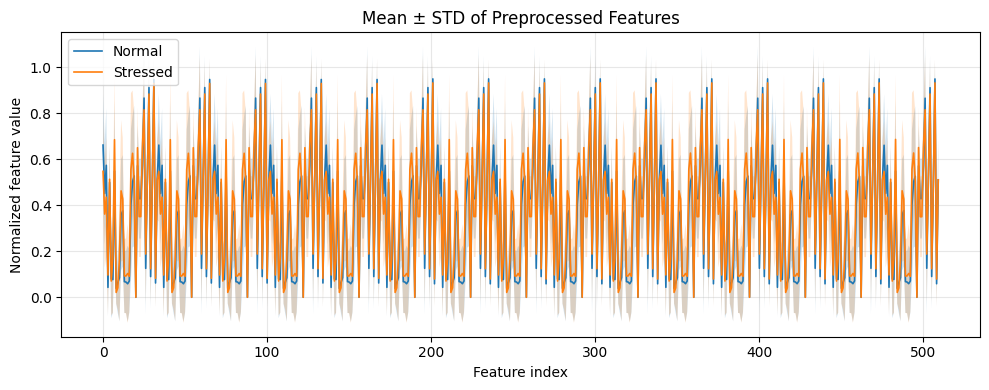

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

X = np.load("/content/X_all.npy")
y = np.load("/content/y_all.npy")

X0 = X[y == 0]
X1 = X[y == 1]

mean0 = X0.mean(axis=0)
std0  = X0.std(axis=0)

mean1 = X1.mean(axis=0)
std1  = X1.std(axis=0)

f = np.arange(X.shape[1])

plt.figure(figsize=(10, 4))
plt.plot(f, mean0, label="Normal", linewidth=1.2)
plt.fill_between(f, mean0 - std0, mean0 + std0, alpha=0.2)

plt.plot(f, mean1, label="Stressed", linewidth=1.2)
plt.fill_between(f, mean1 - std1, mean1 + std1, alpha=0.2)

plt.xlabel("Feature index")
plt.ylabel("Normalized feature value")
plt.title("Mean ± STD of Preprocessed Features")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


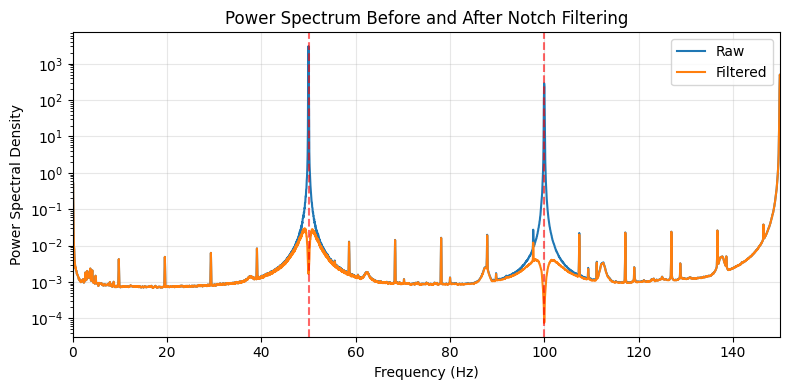

In [ ]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import iirnotch, filtfilt, welch

#Load raw signal
mat_path = "/content/GeneralStressPaperData/generalstress_drought_channelG3C6.mat"
with h5py.File(mat_path, "r") as f:
    raw = np.array(f["mV"]).squeeze()


#Apply notch filters
Q = 30
b50, a50 = iirnotch(50 / (fs / 2), Q)
b100, a100 = iirnotch(100 / (fs / 2), Q)

filtered = filtfilt(b50, a50, raw)
filtered = filtfilt(b100, a100, filtered)

#Power Spectral Density
f_raw, P_raw = welch(raw, fs=fs, nperseg=8192)
f_filt, P_filt = welch(filtered, fs=fs, nperseg=8192)


plt.figure(figsize=(8, 4))
plt.semilogy(f_raw, P_raw, label="Raw")
plt.semilogy(f_filt, P_filt, label="Filtered")
plt.axvline(50, color="r", linestyle="--", alpha=0.6)
plt.axvline(100, color="r", linestyle="--", alpha=0.6)
plt.xlim(0, 150)
plt.xlabel("Frequency (Hz)")
plt.ylabel("Power Spectral Density")
plt.title("Power Spectrum Before and After Notch Filtering")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


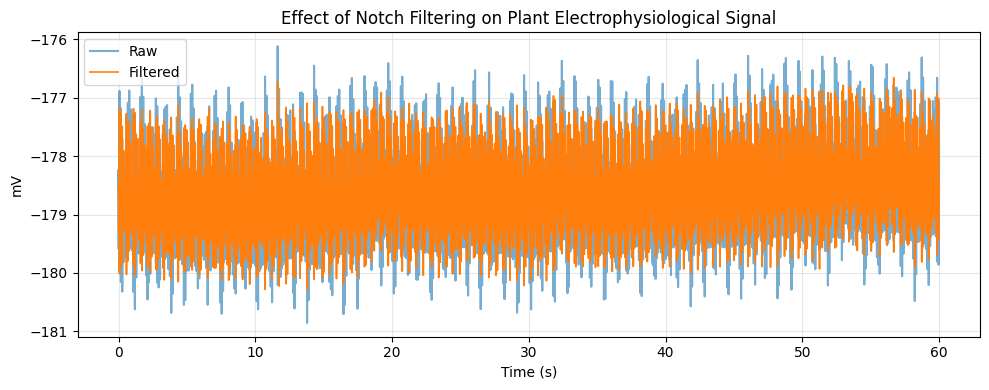

In [ ]:
import numpy as np
import h5py
import matplotlib.pyplot as plt
from scipy.signal import iirnotch, filtfilt

#Load one raw signal
mat_path = "/content/GeneralStressPaperData/generalstress_drought_channelG3C6.mat"
with h5py.File(mat_path, "r") as f:
    raw = np.array(f["mV"]).squeeze()


#Notch filters
Q = 30
b50, a50 = iirnotch(50/(fs/2), Q)
b100, a100 = iirnotch(100/(fs/2), Q)

filtered = filtfilt(b50, a50, raw)
filtered = filtfilt(b100, a100, filtered)

#Plot short segment for clarity (60 s)
T = 60 * fs
t = np.arange(T) / fs

plt.figure(figsize=(10, 4))
plt.plot(t, raw[:T], label="Raw", alpha=0.6)
plt.plot(t, filtered[:T], label="Filtered", linewidth=1.2)
plt.xlabel("Time (s)")
plt.ylabel("mV")
plt.title("Effect of Notch Filtering on Plant Electrophysiological Signal")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()
